# 연도별 기후 특보 횟수를 시각화(추가 시각화)
## 연도별로 폭염,한파, 호우, 대설, 건조 횟수를 종합

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import numpy as np
import csv
import re
plt.rc('font',family = 'Malgun Gothic')

In [2]:
df1 = pd.read_excel('data/2006~2015.xlsx', engine='openpyxl')
df2 = pd.read_excel('data/2015~2024.xlsx', engine='openpyxl')
df3 = pd.read_excel('data/2024~2025.xlsx', engine='openpyxl')
df = pd.concat([df1,df2,df3],axis=0,join='inner',ignore_index=True)
df.drop(columns=['Unnamed: 1'],inplace=True)
display(df)

,특보통보
0,발표시각
1,38719.458333
2,발효시각
3,(1) 건조주의보 해제 : 2006년 01월 02일 11시 00분
4,해당지역
...,...
562195,발효시각
562196,(1) 대설경보 변경 : 2025년 12월 31일 22시 30분
562197,해당지역
562198,(1) 대설경보 변경 : 울릉도.독도


### 발효시각 다음에 특보와 시간이 나오는 행만 추출

In [3]:
#' 발효시각 다음행 추출
target_index = df[df['특보통보']=='발효시각'].index
df_target = df.loc[target_index+1]
df_target

,특보통보
3,(1) 건조주의보 해제 : 2006년 01월 02일 11시 00분
11,(1) 건조주의보 해제 : 2006년 01월 02일 11시 00분
19,(1) 건조주의보 발표 : 2006년 01월 04일 11시 00분(2) 풍랑주의보 ...
27,(1) 건조주의보 발표 : 2006년 01월 04일 11시 00분(2) 풍랑주의보 ...
35,(1) 대설주의보 발표 : 2006년 01월 04일 21시 00분
...,...
562151,(1) 건조주의보 발표 : 2025년 12월 31일 10시 00분
562172,(1) 대설주의보 발표 : 2025년 12월 31일 20시 00분
562180,(1) 대설주의보 발표 : 2025년 12월 31일 20시 00분
562188,(1) 대설경보 변경 : 2025년 12월 31일 22시 30분


In [4]:
# 각자 포함된 특보에 대한 데이터프레임 생성
df_hot = df_target[df_target['특보통보'].str.contains('폭염')]
df_rain = df_target[df_target['특보통보'].str.contains('호우')]
df_snow = df_target[df_target['특보통보'].str.contains('대설')]
df_cold = df_target[df_target['특보통보'].str.contains('한파')]
df_dry = df_target[df_target['특보통보'].str.contains('건조')]



In [5]:
# 'year'열을 생성
df_rain['year'] = 0
df_hot['year'] = 0
df_dry['year'] = 0
df_cold['year'] = 0
df_snow['year'] = 0

for i in range(2006,2026):
    df_hot.loc[df_hot['특보통보'].str.contains(str(i)),'year'] = i
    df_rain.loc[df_rain['특보통보'].str.contains(str(i)),'year'] = i
    df_dry.loc[df_dry['특보통보'].str.contains(str(i)),'year'] = i
    df_cold.loc[df_cold['특보통보'].str.contains(str(i)),'year'] = i
    df_snow.loc[df_snow['특보통보'].str.contains(str(i)),'year'] = i

C:\Users\KDS12\AppData\Local\Temp\ipykernel_9008\3074069883.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rain['year'] = 0
C:\Users\KDS12\AppData\Local\Temp\ipykernel_9008\3074069883.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hot['year'] = 0
C:\Users\KDS12\AppData\Local\Temp\ipykernel_9008\3074069883.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [6]:
print(df_rain['year'].value_counts())
df_rain = df_rain.query('year !=0')
print(df_rain['year'].value_counts())

year
2023    2641
2024    2433
2025    2130
2021    1752
2020    1649
2011    1609
2010    1488
2018    1431
2022    1368
2019    1294
2017    1252
2009    1159
2012    1131
2013    1115
2007    1103
2008    1066
2016     935
2014     927
2006     771
2015     674
0          2
Name: count, dtype: int64
year
2023    2641
2024    2433
2025    2130
2021    1752
2020    1649
2011    1609
2010    1488
2018    1431
2022    1368
2019    1294
2017    1252
2009    1159
2012    1131
2013    1115
2007    1103
2008    1066
2016     935
2014     927
2006     771
2015     674
Name: count, dtype: int64


In [7]:
print(df_hot['year'].value_counts())

year
2024    531
2025    483
2017    447
2022    403
2023    375
2016    347
2019    335
2008    325
2013    299
2010    293
2018    291
2020    287
2021    250
2015    220
2012    206
2011    199
2014    170
2009    167
2007    119
Name: count, dtype: int64


In [8]:
print(df_snow['year'].value_counts())

year
2025    1436
2024     964
2014     840
2023     826
2022     744
2021     734
2012     732
2010     699
2018     680
2013     662
2011     603
2016     583
2017     528
2008     461
2009     439
2020     425
2015     424
2006     360
2007     261
2019     256
Name: count, dtype: int64


In [9]:
print(df_dry['year'].value_counts())

year
2009    474
2017    448
2015    406
2014    398
2019    390
2022    382
2020    362
2016    336
2023    332
2011    318
2018    317
2013    310
2012    308
2021    281
2010    264
2025    256
2008    218
2006    140
2007    134
2024    126
Name: count, dtype: int64


In [10]:
print(df_cold['year'].value_counts())

year
2022    294
2023    253
2021    238
2011    232
2012    221
2018    220
2014    219
2013    202
2025    196
2016    183
2017    181
2019    180
2010    151
2024    135
2009    115
2020    115
2015     86
2008     45
2006      7
Name: count, dtype: int64


## 차트 시각화

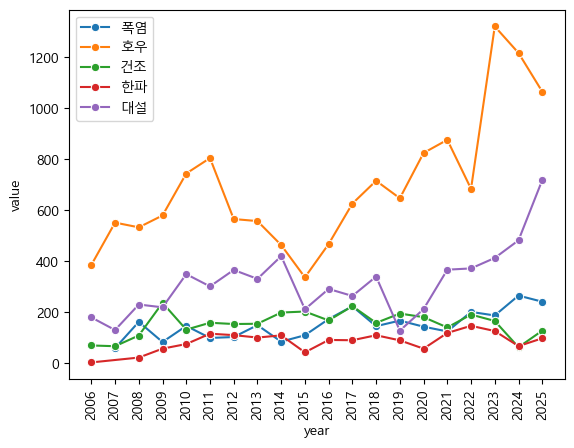

In [11]:
year_count_hot = df_hot['year'].value_counts().sort_index().div(2).reset_index()
year_count_rain = df_rain['year'].value_counts().sort_index().div(2).reset_index()
year_count_cold = df_cold['year'].value_counts().sort_index().div(2).reset_index()
year_count_dry = df_dry['year'].value_counts().sort_index().div(2).reset_index()
year_count_snow = df_snow['year'].value_counts().sort_index().div(2).reset_index()
year_count_hot.columns = ['year','value']
year_count_rain.columns = ['year','value']
year_count_cold.columns = ['year','value']
year_count_dry.columns = ['year','value']
year_count_snow.columns = ['year','value']


sns.lineplot(data=year_count_hot,x='year',y='value',marker='o',label='폭염')
sns.lineplot(data=year_count_rain,x='year',y='value',marker='o',label='호우')
sns.lineplot(data=year_count_dry,x='year',y='value',marker='o',label='건조')
sns.lineplot(data=year_count_cold,x='year',y='value',marker='o',label='한파')
sns.lineplot(data=year_count_snow,x='year',y='value',marker='o',label='대설')


plt.legend()
plt.xticks(range(2006,2026),rotation=90)
plt.show()

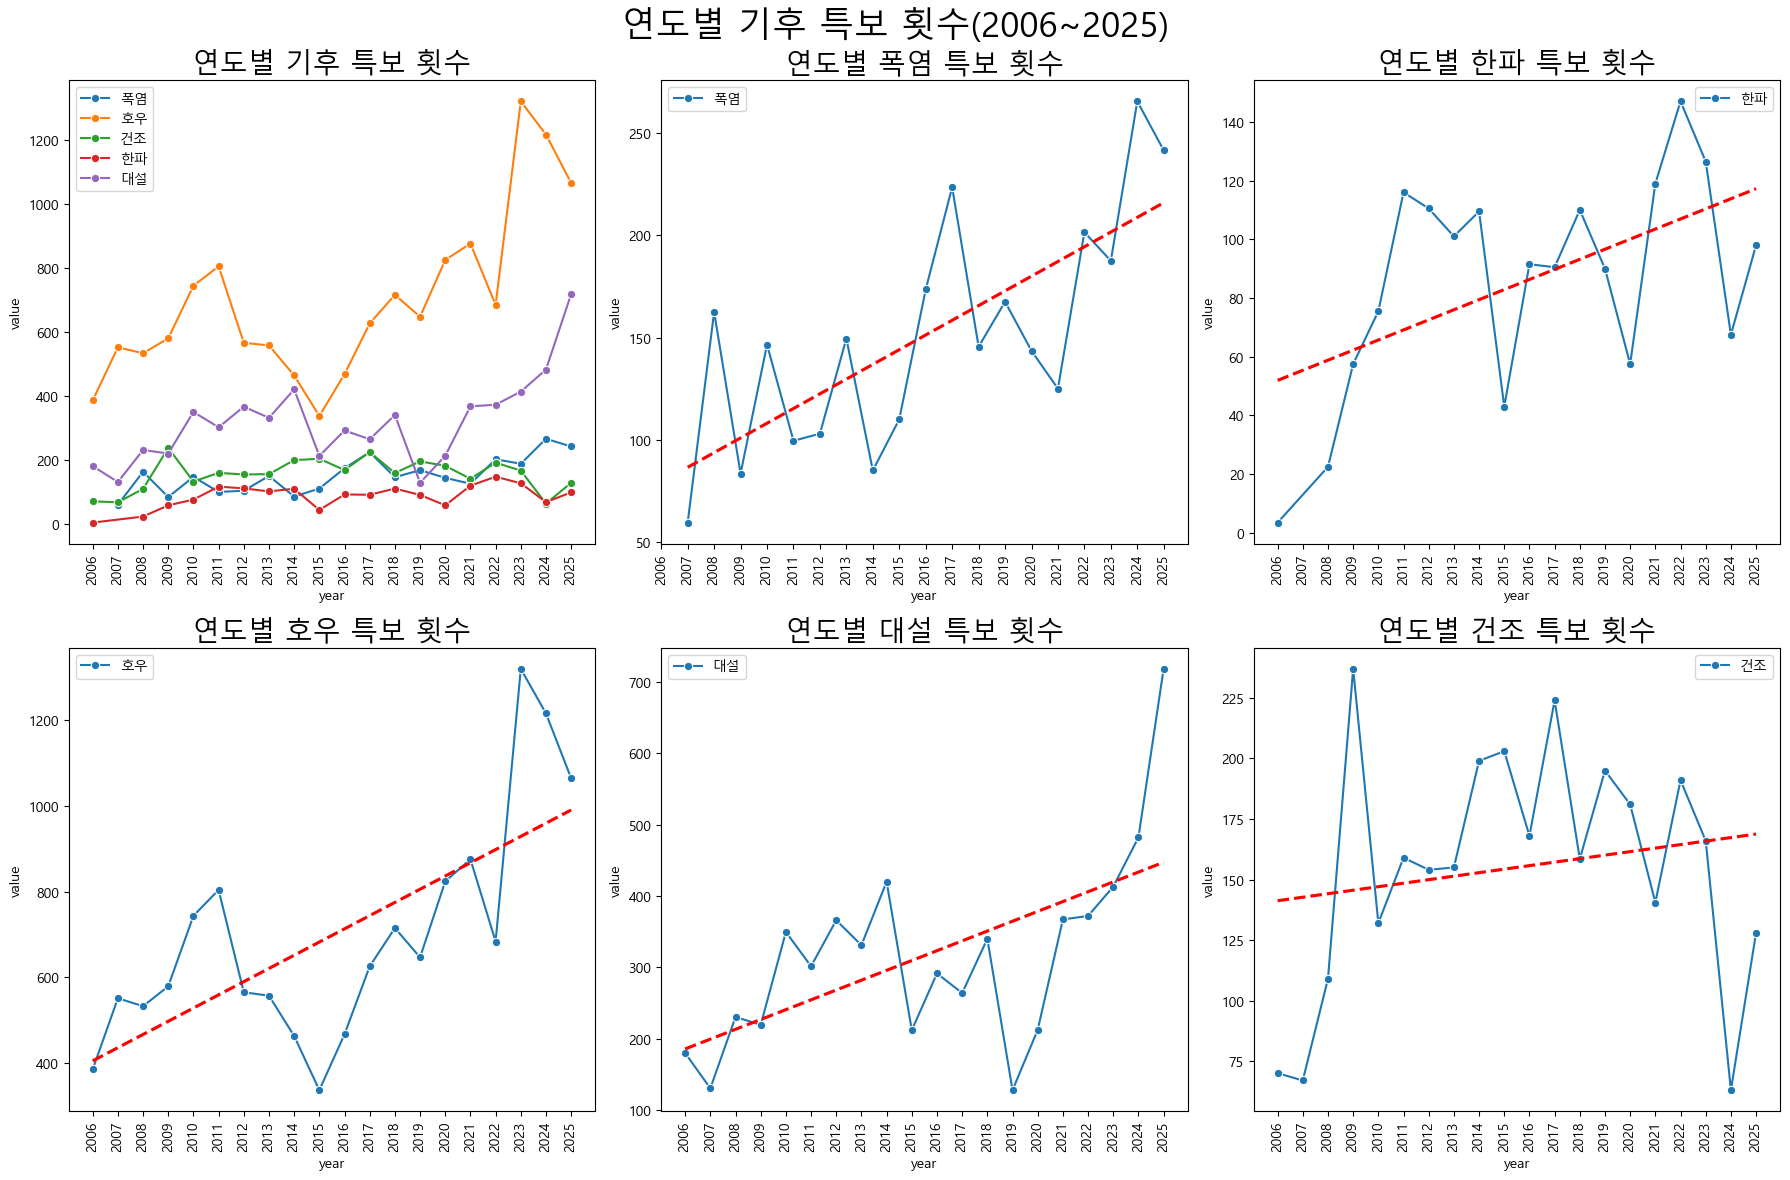

In [12]:
fig,ax = plt.subplots(2,3,figsize=(18,12))
fig.suptitle('연도별 기후 특보 횟수(2006~2025)',size=25)
sns.lineplot(data=year_count_hot,x='year',y='value',marker='o',label='폭염',ax = ax[0,0])
sns.lineplot(data=year_count_rain,x='year',y='value',marker='o',label='호우',ax = ax[0,0])
sns.lineplot(data=year_count_dry,x='year',y='value',marker='o',label='건조',ax = ax[0,0])
sns.lineplot(data=year_count_cold,x='year',y='value',marker='o',label='한파',ax = ax[0,0])
sns.lineplot(data=year_count_snow,x='year',y='value',marker='o',label='대설',ax = ax[0,0])

ax[0,0].set_title('연도별 기후 특보 횟수',size=20)
ax[0,0].set_xticks(range(2006,2026))
ax[0,0].tick_params(axis='x', rotation=90)

sns.lineplot(data=year_count_hot,x='year',y='value',marker='o',label='폭염',ax = ax[0,1])
sns.regplot(data=year_count_hot,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax = ax[0,1])
ax[0,1].set_title('연도별 폭염 특보 횟수',size=20)
ax[0,1].set_xticks(range(2006,2026))
ax[0,1].tick_params(axis='x', rotation=90)

sns.lineplot(data=year_count_cold,x='year',y='value',marker='o',label='한파',ax = ax[0,2])
sns.regplot(data=year_count_cold,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax = ax[0,2])
ax[0,2].set_title('연도별 한파 특보 횟수',size=20)
ax[0,2].set_xticks(range(2006,2026))
ax[0,2].tick_params(axis='x', rotation=90)

sns.lineplot(data=year_count_rain,x='year',y='value',marker='o',label='호우',ax = ax[1,0])
sns.regplot(data=year_count_rain,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax = ax[1,0])
ax[1,0].set_title('연도별 호우 특보 횟수',size=20)
ax[1,0].set_xticks(range(2006,2026))
ax[1,0].tick_params(axis='x', rotation=90)

sns.lineplot(data=year_count_snow,x='year',y='value',marker='o',label='대설',ax = ax[1,1])
sns.regplot(data=year_count_snow,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax = ax[1,1])
ax[1,1].set_title('연도별 대설 특보 횟수',size=20)
ax[1,1].set_xticks(range(2006,2026))
ax[1,1].tick_params(axis='x', rotation=90)

sns.lineplot(data=year_count_dry,x='year',y='value',marker='o',label='건조',ax = ax[1,2])
sns.regplot(data=year_count_dry,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax = ax[1,2])
ax[1,2].set_title('연도별 건조 특보 횟수',size=20)
ax[1,2].set_xticks(range(2006,2026))
ax[1,2].tick_params(axis='x', rotation=90)

plt.legend()

plt.tight_layout()
plt.show()

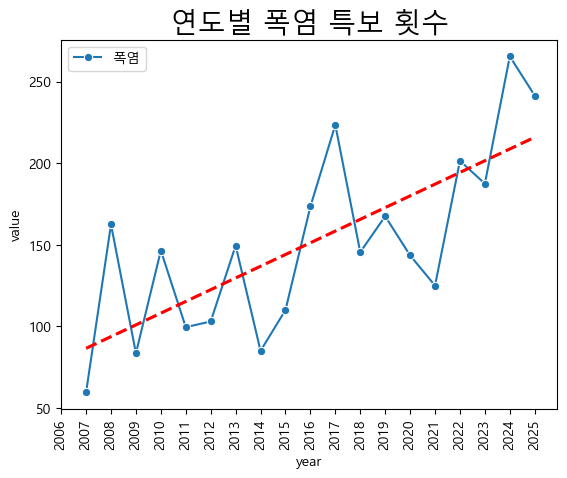

In [13]:
ax = sns.lineplot(data=year_count_hot,x='year',y='value',marker='o',label='폭염')
sns.regplot(data=year_count_hot,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax=ax)
plt.title('연도별 폭염 특보 횟수',size=20)
plt.legend()
plt.xticks(range(2006,2026),rotation=90)
plt.show()

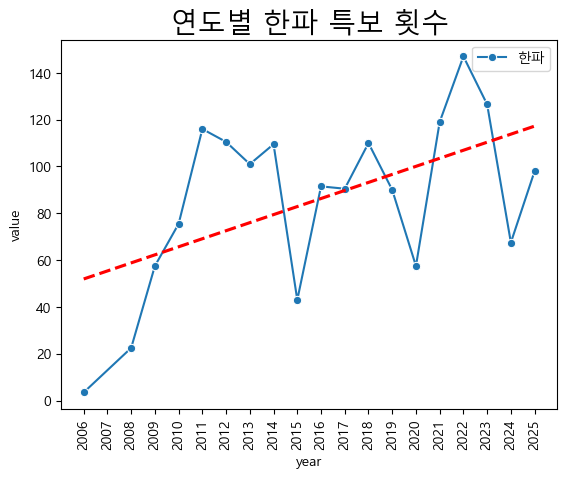

In [14]:
ax = sns.lineplot(data=year_count_cold,x='year',y='value',marker='o',label='한파')
sns.regplot(data=year_count_cold,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax=ax)
plt.title('연도별 한파 특보 횟수',size=20)
plt.xticks(range(2006,2026),rotation=90)
plt.legend()
plt.show()

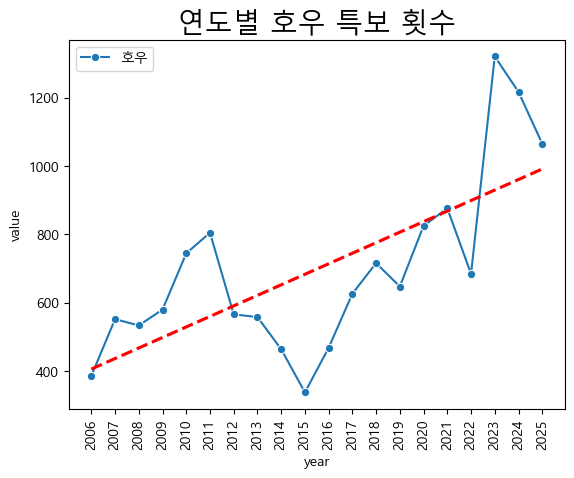

In [15]:
ax = sns.lineplot(data=year_count_rain,x='year',y='value',marker='o',label='호우')
sns.regplot(data=year_count_rain,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax=ax)
plt.title('연도별 호우 특보 횟수',size=20)
plt.xticks(range(2006,2026),rotation=90)
plt.legend()
plt.show()

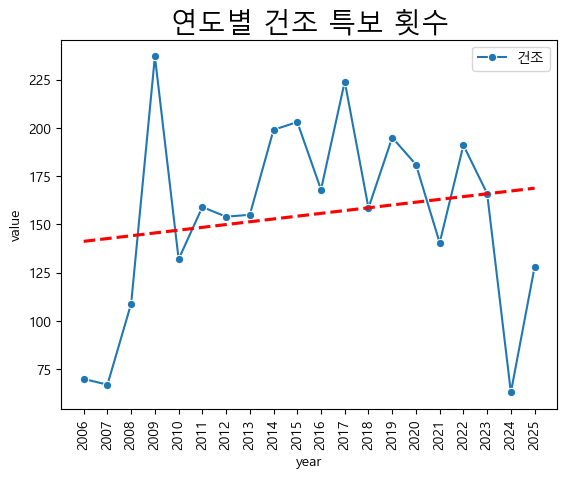

In [16]:
ax = sns.lineplot(data=year_count_dry,x='year',y='value',marker='o',label='건조')
sns.regplot(data=year_count_dry,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax=ax)
plt.title('연도별 건조 특보 횟수',size=20)
plt.xticks(range(2006,2026),rotation=90)
plt.legend()
plt.show()

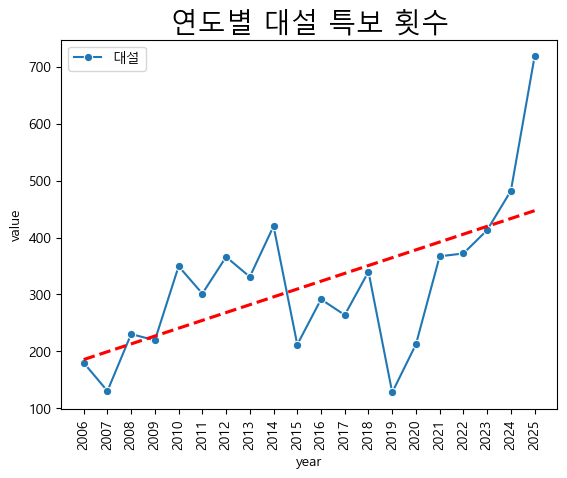

In [17]:
ax = sns.lineplot(data=year_count_snow,x='year',y='value',marker='o',label='대설')
sns.regplot(data=year_count_snow,x='year',y='value',ci=None,line_kws={"color": "red",'linestyle':'--'},scatter=False,marker='o',ax=ax)
plt.title('연도별 대설 특보 횟수',size=20)
plt.xticks(range(2006,2026),rotation=90)
plt.legend()
plt.show()